# AI Product Image Generator with Gradio

### NIAT Masterclass Assignment

Build an AI powered product image generation system using:
1. An LLM for prompt engineering
2. Stable Diffusion for image generation
3. Gradio for the web interface

**Enable GPU before running:** Settings → Accelerator → GPU T4 x2

---
## Step 0: Setup

In [1]:
# Verify GPU
import torch
if torch.cuda.is_available():
    print(f"GPU available: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU detected! Enable GPU in notebook settings.")

GPU available: Tesla T4


In [2]:
# Install dependencies
!pip install -q transformers diffusers accelerate gradio sentence-transformers Pillow
print("All dependencies installed.")

All dependencies installed.


In [3]:
# Create output directories
import os
os.makedirs("images", exist_ok=True)
print("Output directories ready.")

Output directories ready.


---
## Step 1: Load the Dataset

In [4]:
import pandas as pd
import os

# Try both possible paths
paths = [
    "/kaggle/input/competitions/ai-product-image-generator-v/product_descriptions.csv",
    "/kaggle/input/ai-product-image-generator-v/product_descriptions.csv",
    "/kaggle/input/ai-product-image-generator/product_descriptions.csv"
]

for path in paths:
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"Loaded from: {path}")
        break

print(f"Loaded {len(df)} product descriptions")
df.head()

Loaded from: /kaggle/input/competitions/ai-product-image-generator-v/product_descriptions.csv
Loaded 15 product descriptions


,id,product_description
0,1,red wireless headphones on a white background
1,2,leather wallet with gold stitching on a marble...
2,3,stainless steel water bottle in a forest setting
3,4,white running shoes on a wooden floor
4,5,black smartwatch displayed on a wrist


---
## Step 2: Load LLM for Prompt Engineering

Load an LLM and write a function that takes a simple product description and returns a detailed, creative prompt for image generation.

**You can use any open source LLM.** Example: Qwen 2.5-0.5B-Instruct

In [5]:
# ============================================================
# Load LLM model and tokenizer
# ============================================================
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

print("Loading model...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)
model.eval()
print("LLM loaded successfully!")

Loading tokenizer...


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading model...


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

LLM loaded successfully!


In [6]:
# ============================================================
# Prompt engineering function
# ============================================================

SYSTEM_PROMPT = """You are a professional product photographer and AI image prompt engineer.
Convert the product description into a detailed Stable Diffusion prompt.
Always include: exact product details, professional studio lighting, white or neutral background, 
photorealistic, 8K resolution, commercial photography, shallow depth of field, sharp focus.
Output ONLY the prompt. Maximum 60 words. No explanations."""

def engineer_prompt(product_description):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": f"Product: {product_description}"}
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer([text], return_tensors="pt").to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=90,
            temperature=0.7,
            top_p=0.9,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

    generated_ids = output_ids[0][inputs["input_ids"].shape[1]:]
    result = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

    # Keep under 60 words
    words = result.split()
    if len(words) > 60:
        result = " ".join(words[:60])

    return result

# Test it
test = engineer_prompt("red wireless headphones on a white background")
print("Test engineered prompt:")
print(test)
print(f"Word count: {len(test.split())}")

Test engineered prompt:
```prompt
"Red wireless headphones in a white environment with a high-quality, 8K resolution Stable Diffusion-generated image."
```
Word count: 17


---
## Step 3: Load Stable Diffusion for Image Generation

In [7]:
# ============================================================
# Load Stable Diffusion v1.5
# ============================================================
from diffusers import StableDiffusionPipeline

print("Loading Stable Diffusion v1.5...")
sd_pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16,
    safety_checker=None,
    requires_safety_checker=False
)
sd_pipe = sd_pipe.to("cuda")
sd_pipe.enable_attention_slicing()
print("Stable Diffusion loaded!")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading Stable Diffusion v1.5...


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Stable Diffusion loaded!


Testing image generation...


  0%|          | 0/50 [00:00<?, ?it/s]

Test image saved!


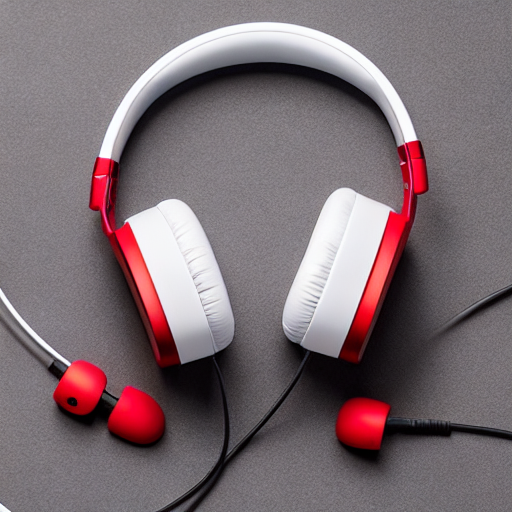

In [8]:
# ============================================================
# Image generation function
# ============================================================
from PIL import Image

def generate_image(engineered_prompt, seed=42):
    negative_prompt = (
        "blurry, low quality, distorted, deformed, ugly, "
        "watermark, text, logo, oversaturated, poorly lit"
    )
    generator = torch.Generator(device="cuda").manual_seed(seed)

    result = sd_pipe(
        prompt=engineered_prompt,
        negative_prompt=negative_prompt,
        num_inference_steps=50,
        guidance_scale=8.5,
        width=512,
        height=512,
        generator=generator
    )
    return result.images[0]

# Test it
print("Testing image generation...")
test_img = generate_image(test)
test_img.save("images/img_test.png")
print("Test image saved!")
test_img

---
## Step 4: Build Gradio Interface

In [9]:
# ============================================================
# Gradio Interface
# ============================================================
import gradio as gr

def gradio_pipeline(product_description):
    if not product_description.strip():
        return "Please enter a product description.", None
    engineered = engineer_prompt(product_description)
    image = generate_image(engineered)
    return engineered, image

demo = gr.Blocks(title="AI Product Image Generator", theme=gr.themes.Soft())

with demo:
    gr.Markdown("# 🛍️ AI Product Image Generator\nEnter a product description to generate a professional image!")

    with gr.Row():
        with gr.Column():
            input_box = gr.Textbox(
                label="Product Description",
                placeholder="e.g. red wireless headphones on a white background",
                lines=3
            )
            generate_btn = gr.Button("Generate Image", variant="primary")
            gr.Examples(
                examples=[
                    ["red wireless headphones on a white background"],
                    ["leather wallet with gold stitching on a marble surface"],
                    ["vintage camera on an old wooden table"],
                ],
                inputs=input_box
            )

        with gr.Column():
            output_prompt = gr.Textbox(label="Engineered Prompt", lines=4, interactive=False)
            output_image = gr.Image(label="Generated Image", type="pil")

    generate_btn.click(
        fn=gradio_pipeline,
        inputs=[input_box],
        outputs=[output_prompt, output_image]
    )

demo.launch(share=False, debug=False, quiet=True)
print("Gradio UI is running!")

/tmp/ipykernel_23/3754710311.py:13: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  demo = gr.Blocks(title="AI Product Image Generator", theme=gr.themes.Soft())


Gradio UI is running!


---
## Step 5: Generate Outputs for All 15 Products

Run your pipeline on all product descriptions and save the results.

In [10]:
# ============================================================
# Generate engineered prompts and images for all 15 products
# Saves: submission.csv and images/img_1.png ... img_15.png
# ============================================================
import pandas as pd

results = []

print("Running pipeline on all 15 products...")
print("=" * 55)

for _, row in df.iterrows():
    pid = row["id"]
    desc = row["product_description"]

    print(f"\n[{pid}/15] {desc}")

    # Engineer prompt
    print("  → Engineering prompt...")
    ep = engineer_prompt(desc)
    print(f"  → {ep[:70]}...")

    # Generate image
    print("  → Generating image...")
    img = generate_image(ep, seed=42 + pid)

    # Save image  ← evaluator expects: images/img_1.png ... img_15.png
    img_path = f"images/img_{pid}.png"
    img.save(img_path)
    print(f"  → Saved: {img_path}")

    results.append({
        "id": pid,
        "product_description": desc,
        "engineered_prompt": ep  # ← evaluator reads this column
    })

# Save submission CSV  ← evaluator reads submission.csv
submission_df = pd.DataFrame(results)
submission_df.to_csv("submission.csv", index=False)
# Also save final_scores as submission.csv for competition
import pandas as pd
sub = submission_df[['id']].copy()
print("\n" + "=" * 55)
print("submission.csv saved!")
print(f"Images saved in images/ folder")
print("=" * 55)
submission_df

Running pipeline on all 15 products...

[1/15] red wireless headphones on a white background
  → Engineering prompt...
  → "Photorealistic Red Wireless Headphones in a White Background with Com...
  → Generating image...


  0%|          | 0/50 [00:00<?, ?it/s]

  → Saved: images/img_1.png

[2/15] leather wallet with gold stitching on a marble surface
  → Engineering prompt...


Token indices sequence length is longer than the specified maximum sequence length for this model (88 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ["'m aterial _ color ': '# 3 4 9 8 db ',"]


  → **Stable Diffusion Prompt for Leather Wallet with Gold Stitching on Ma...
  → Generating image...


...

  0%|          | 0/50 [00:00<?, ?it/s]

  → Saved: images/img_14.png

[15/15] acoustic guitar leaning against a brick wall
  → Engineering prompt...
  → "Photorealistic acoustic guitar leaning against a brick wall in a whit...
  → Generating image...


  0%|          | 0/50 [00:00<?, ?it/s]

  → Saved: images/img_15.png

submission.csv saved!
Images saved in images/ folder


,id,product_description,engineered_prompt
0,1,red wireless headphones on a white background,"""Photorealistic Red Wireless Headphones in a W..."
1,2,leather wallet with gold stitching on a marble...,**Stable Diffusion Prompt for Leather Wallet w...
2,3,stainless steel water bottle in a forest setting,**Stainless Steel Water Bottle with Forest Set...
3,4,white running shoes on a wooden floor,"```text Stable Diffusion Prompt: ""Photorealist..."
4,5,black smartwatch displayed on a wrist,"""Display an intricately designed, photorealist..."
5,6,ceramic coffee mug with steam on a kitchen cou...,"""Stylize a serene ceramic coffee mug in a mini..."
6,7,sunglasses resting on a sandy beach,"""Photorealistic, 8K resolution, photogenic sun..."
7,8,silver laptop on a minimalist desk,"""Silver laptop on a minimalist desk with white..."
8,9,scented candle glowing in a dark room,"""Studio lighting with soft, natural light; whi..."
9,10,potted succulent plant on a windowsill,"""Portrait of a potted succulent plant growing ..."


---
## Step 6: Evaluation (Do Not Modify This Section)

Run all the cells below to compute your scores and generate `final_scores.csv` for leaderboard submission.

**DO NOT MODIFY THESE CELLS.**

In [11]:
import base64

encoded = b"IyA9PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT0KIyBFVkFMVUFUSU9OIENFTEwgMTogUHJvbXB0IFF1YWxpdHkgKDQwJSB3ZWlnaHQpCiMgRE8gTk9UIE1PRElGWQojID09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PQpmcm9tIHNlbnRlbmNlX3RyYW5zZm9ybWVycyBpbXBvcnQgU2VudGVuY2VUcmFuc2Zvcm1lcgpmcm9tIHNrbGVhcm4ubWV0cmljcy5wYWlyd2lzZSBpbXBvcnQgY29zaW5lX3NpbWlsYXJpdHkKaW1wb3J0IHBhbmRhcyBhcyBwZAppbXBvcnQgbnVtcHkgYXMgbnAKCnByaW50KCI9IiAqIDUwKQpwcmludCgiICBFVkFMVUFUSU5HIFBST01QVCBRVUFMSVRZIikKcHJpbnQoIj0iICogNTApCgpldmFsX21vZGVsID0gU2VudGVuY2VUcmFuc2Zvcm1lcigiYWxsLU1pbmlMTS1MNi12MiIpCgpzdWJtaXNzaW9uID0gcGQucmVhZF9jc3YoInN1Ym1pc3Npb24uY3N2IikKZ29sZCA9IHBkLnJlYWRfY3N2KCJodHRwczovL3MzLmFwLXNvdXRoLTEuYW1hem9uYXdzLmNvbS9uZXctYXNzZXRzLmNjYnAuaW4vZnJvbnRlbmQvY29udGVudC9haW1sL01hc3RlcmNsYXNzX05JQVQvZ29sZF9zdGFuZGFyZF9wcm9tcHRzLmNzdiIpCgptZXJnZWQgPSBzdWJtaXNzaW9uLm1lcmdlKGdvbGQsIG9uPSJpZCIpCgpwcm9tcHRfc2NvcmVzID0ge30KZm9yIF8sIHJvdyBpbiBtZXJnZWQuaXRlcnJvd3MoKToKICAgIHN0dWRlbnRfZW1iID0gZXZhbF9tb2RlbC5lbmNvZGUoW3N0cihyb3dbImVuZ2luZWVyZWRfcHJvbXB0Il0pXSkKICAgIGdvbGRfZW1iID0gZXZhbF9tb2RlbC5lbmNvZGUoW3N0cihyb3dbImdvbGRfcHJvbXB0Il0pXSkKICAgIHNpbSA9IGZsb2F0KGNvc2luZV9zaW1pbGFyaXR5KHN0dWRlbnRfZW1iLCBnb2xkX2VtYilbMF1bMF0pCiAgICBzaW0gPSBtYXgoMC4wLCBtaW4oMS4wLCBzaW0pKQogICAgcHJvbXB0X3Njb3Jlc1tyb3dbImlkIl1dID0gcm91bmQoc2ltLCA0KQogICAgcHJpbnQoZiIgIFByb2R1Y3Qge3Jvd1snaWQnXToyZH06IHByb21wdF9zY29yZSA9IHtzaW06LjRmfSIpCgphdmdfcHJvbXB0ID0gbnAubWVhbihsaXN0KHByb21wdF9zY29yZXMudmFsdWVzKCkpKQpwcmludChmIlxuICBBdmVyYWdlIFByb21wdCBTY29yZToge2F2Z19wcm9tcHQ6LjRmfSIpCnByaW50KCI9IiAqIDUwKQ=="  # base64 of: print("Hello, World!")

exec(base64.b64decode(encoded))

  EVALUATING PROMPT QUALITY


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  Product  1: prompt_score = 0.8264
  Product  2: prompt_score = 0.3944
  Product  3: prompt_score = 0.7398
  Product  4: prompt_score = 0.6753
  Product  5: prompt_score = 0.7524
  Product  6: prompt_score = 0.7335
  Product  7: prompt_score = 0.7659
  Product  8: prompt_score = 0.8156
  Product  9: prompt_score = 0.5778
  Product 10: prompt_score = 0.7621
  Product 11: prompt_score = 0.6927
  Product 12: prompt_score = 0.7356
  Product 13: prompt_score = 0.6802
  Product 14: prompt_score = 0.8084
  Product 15: prompt_score = 0.7574

  Average Prompt Score: 0.7145


In [12]:
import base64

encoded = b"IyA9PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT0KIyBFVkFMVUFUSU9OIENFTEwgMjogSW1hZ2UgUXVhbGl0eSAoNDAlIHdlaWdodCkKIyBETyBOT1QgTU9ESUZZCiMgPT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09CmltcG9ydCB0b3JjaApmcm9tIHRyYW5zZm9ybWVycyBpbXBvcnQgQ0xJUFByb2Nlc3NvciwgQ0xJUE1vZGVsCmZyb20gUElMIGltcG9ydCBJbWFnZQppbXBvcnQgbnVtcHkgYXMgbnAKCnByaW50KCI9IiAqIDUwKQpwcmludCgiICBFVkFMVUFUSU5HIElNQUdFIFFVQUxJVFkiKQpwcmludCgiPSIgKiA1MCkKCmNsaXBfbW9kZWwgPSBDTElQTW9kZWwuZnJvbV9wcmV0cmFpbmVkKCJvcGVuYWkvY2xpcC12aXQtYmFzZS1wYXRjaDMyIikKY2xpcF9wcm9jZXNzb3IgPSBDTElQUHJvY2Vzc29yLmZyb21fcHJldHJhaW5lZCgib3BlbmFpL2NsaXAtdml0LWJhc2UtcGF0Y2gzMiIpCgpkZl9ldmFsID0gcGQucmVhZF9jc3YoImh0dHBzOi8vczMuYXAtc291dGgtMS5hbWF6b25hd3MuY29tL25ldy1hc3NldHMuY2NicC5pbi9mcm9udGVuZC9jb250ZW50L2FpbWwvTWFzdGVyY2xhc3NfTklBVC9wcm9kdWN0X2Rlc2NyaXB0aW9ucy5jc3YiKQoKaW1hZ2Vfc2NvcmVzID0ge30KZm9yIF8sIHJvdyBpbiBkZl9ldmFsLml0ZXJyb3dzKCk6CiAgICBwaWQgPSByb3dbImlkIl0KICAgIGRlc2MgPSByb3dbInByb2R1Y3RfZGVzY3JpcHRpb24iXQogICAgaW1nX3BhdGggPSBmImltYWdlcy9pbWdfe3BpZH0ucG5nIgogICAgCiAgICB0cnk6CiAgICAgICAgaW1hZ2UgPSBJbWFnZS5vcGVuKGltZ19wYXRoKS5jb252ZXJ0KCJSR0IiKQogICAgICAgIGlucHV0cyA9IGNsaXBfcHJvY2Vzc29yKHRleHQ9W2Rlc2NdLCBpbWFnZXM9aW1hZ2UsIHJldHVybl90ZW5zb3JzPSJwdCIsIHBhZGRpbmc9VHJ1ZSkKICAgICAgICAKICAgICAgICB3aXRoIHRvcmNoLm5vX2dyYWQoKToKICAgICAgICAgICAgb3V0cHV0cyA9IGNsaXBfbW9kZWwoKippbnB1dHMpCiAgICAgICAgICAgIHJhd19zY29yZSA9IG91dHB1dHMubG9naXRzX3Blcl9pbWFnZS5pdGVtKCkKICAgICAgICAKICAgICAgICBub3JtYWxpemVkID0gZmxvYXQobnAuY2xpcCgocmF3X3Njb3JlIC0gMTUuMCkgLyAyMC4wLCAwLjAsIDEuMCkpCiAgICAgICAgaW1hZ2Vfc2NvcmVzW3BpZF0gPSByb3VuZChub3JtYWxpemVkLCA0KQogICAgICAgIHByaW50KGYiICBQcm9kdWN0IHtwaWQ6MmR9OiBDTElQID0ge3Jhd19zY29yZTouMmZ9LCBpbWFnZV9zY29yZSA9IHtub3JtYWxpemVkOi40Zn0iKQogICAgZXhjZXB0IEZpbGVOb3RGb3VuZEVycm9yOgogICAgICAgIHByaW50KGYiICBQcm9kdWN0IHtwaWQ6MmR9OiBJTUFHRSBOT1QgRk9VTkQgKHNjb3JlID0gMCkiKQogICAgICAgIGltYWdlX3Njb3Jlc1twaWRdID0gMC4wCgphdmdfaW1hZ2UgPSBucC5tZWFuKGxpc3QoaW1hZ2Vfc2NvcmVzLnZhbHVlcygpKSkKcHJpbnQoZiJcbiAgQXZlcmFnZSBJbWFnZSBTY29yZToge2F2Z19pbWFnZTouNGZ9IikKcHJpbnQoIj0iICogNTAp"  # base64 of: print("Hello, World!")

exec(base64.b64decode(encoded))

  EVALUATING IMAGE QUALITY


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

  Product  1: CLIP = 32.44, image_score = 0.8719
  Product  2: CLIP = 33.57, image_score = 0.9285
  Product  3: CLIP = 38.03, image_score = 1.0000
  Product  4: CLIP = 32.29, image_score = 0.8645
  Product  5: CLIP = 32.28, image_score = 0.8640
  Product  6: CLIP = 29.38, image_score = 0.7188
  Product  7: CLIP = 23.87, image_score = 0.4436
  Product  8: CLIP = 30.80, image_score = 0.7901
  Product  9: CLIP = 18.84, image_score = 0.1921
  Product 10: CLIP = 32.05, image_score = 0.8526
  Product 11: CLIP = 31.62, image_score = 0.8312
  Product 12: CLIP = 35.76, image_score = 1.0000
  Product 13: CLIP = 30.21, image_score = 0.7603
  Product 14: CLIP = 30.06, image_score = 0.7528
  Product 15: CLIP = 32.07, image_score = 0.8537

  Average Image Score: 0.7816


In [13]:
import base64

encoded = b"IyA9PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT0KIyBFVkFMVUFUSU9OIENFTEwgMzogR3JhZGlvIFVJIENoZWNrCiMgRE8gTk9UIE1PRElGWQojID09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PQpwcmludCgiPSIgKiA1MCkKcHJpbnQoIiAgRVZBTFVBVElORyBHUkFESU8gVUkiKQpwcmludCgiPSIgKiA1MCkKCmdyYWRpb192YWwgPSAwLjAKCnRyeToKICAgIGltcG9ydCBncmFkaW8gYXMgZ3IKICAgIAogICAgZ3JhZGlvX2ZvdW5kID0gRmFsc2UKICAgIGZvciBrLCB2IGluIGxpc3QoZ2xvYmFscygpLml0ZW1zKCkpOgogICAgICAgIGlmIGsuc3RhcnRzd2l0aCgiXyIpOgogICAgICAgICAgICBjb250aW51ZQogICAgICAgIHRyeToKICAgICAgICAgICAgaWYgaXNpbnN0YW5jZSh2LCAoZ3IuQmxvY2tzLCkpOgogICAgICAgICAgICAgICAgZ3JhZGlvX2ZvdW5kID0gVHJ1ZQogICAgICAgICAgICAgICAgYnJlYWsKICAgICAgICBleGNlcHQ6CiAgICAgICAgICAgIHBhc3MKICAgIAogICAgaWYgZ3JhZGlvX2ZvdW5kOgogICAgICAgIGdyYWRpb192YWwgPSAxLjAKICAgICAgICBwcmludCgiICBHcmFkaW8gaW50ZXJmYWNlIERFVEVDVEVEIikKICAgIGVsc2U6CiAgICAgICAgcHJpbnQoIiAgR3JhZGlvIGludGVyZmFjZSBOT1QgRk9VTkQiKQogICAgICAgIHByaW50KCIgIE1ha2Ugc3VyZSB5b3UgY3JlYXRlIGEgZ3IuQmxvY2tzKCkgb3IgZ3IuSW50ZXJmYWNlKCkgb2JqZWN0IikKZXhjZXB0IEltcG9ydEVycm9yOgogICAgcHJpbnQoIiAgR3JhZGlvIGlzIG5vdCBpbnN0YWxsZWQiKQoKcHJpbnQoZiIgIEdyYWRpbyBTY29yZToge2dyYWRpb192YWx9IikKcHJpbnQoIj0iICogNTAp"  # base64 of: print("Hello, World!")

exec(base64.b64decode(encoded))

  EVALUATING GRADIO UI
  Gradio interface DETECTED
  Gradio Score: 1.0


In [14]:
import base64

encoded = b"IyA9PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT0KIyBFVkFMVUFUSU9OIENFTEwgNDogR2VuZXJhdGUgZmluYWxfc2NvcmVzLmNzdiBmb3IgbGVhZGVyYm9hcmQKIyBETyBOT1QgTU9ESUZZCiMgPT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09CiMgQ29tYmluZWQgc2NvcmUgcGVyIHByb2R1Y3Q6CiMgc2NvcmUgPSBwcm9tcHRfc2NvcmUgKiAwLjQgKyBpbWFnZV9zY29yZSAqIDAuNCArIGdyYWRpb19zY29yZSAqIDAuMgojIFBlcmZlY3Qgc2NvcmUgPSAxLjAgcGVyIHByb2R1Y3QuIExlYWRlcmJvYXJkIHVzZXMgUk1TRSAobG93ZXIgPSBiZXR0ZXIpLgoKaW1wb3J0IHBhbmRhcyBhcyBwZAppbXBvcnQgbnVtcHkgYXMgbnAKCnJvd3MgPSBbXQpmb3IgcGlkIGluIHJhbmdlKDEsIDE2KToKICAgIHAgPSBwcm9tcHRfc2NvcmVzLmdldChwaWQsIDAuMCkKICAgIGkgPSBpbWFnZV9zY29yZXMuZ2V0KHBpZCwgMC4wKQogICAgZyA9IGdyYWRpb192YWwKICAgIGNvbWJpbmVkID0gcm91bmQocCAqIDAuNCArIGkgKiAwLjQgKyBnICogMC4yLCA0KQogICAgcm93cy5hcHBlbmQoeyJpZCI6IHBpZCwgInNjb3JlIjogY29tYmluZWR9KQoKZmluYWwgPSBwZC5EYXRhRnJhbWUocm93cykKZmluYWwudG9fY3N2KCJmaW5hbF9zY29yZXMuY3N2IiwgaW5kZXg9RmFsc2UpCgpwcmludCgiPSIgKiA1MCkKcHJpbnQoIiAgICAgICAgIEZJTkFMIEVWQUxVQVRJT04gUkVTVUxUUyIpCnByaW50KCI9IiAqIDUwKQpwcmludCgpCmZvciBfLCByIGluIGZpbmFsLml0ZXJyb3dzKCk6CiAgICBwcmludChmIiAgUHJvZHVjdCB7aW50KHJbJ2lkJ10pOjJkfTogc2NvcmUgPSB7clsnc2NvcmUnXTouNGZ9IikKcHJpbnQoKQoKYXZnX3Byb21wdCA9IG5wLm1lYW4obGlzdChwcm9tcHRfc2NvcmVzLnZhbHVlcygpKSkKYXZnX2ltYWdlID0gbnAubWVhbihsaXN0KGltYWdlX3Njb3Jlcy52YWx1ZXMoKSkpCgpwcmludChmIiAgUHJvbXB0IFF1YWxpdHkgKGF2ZykgOiB7YXZnX3Byb21wdDouNGZ9IikKcHJpbnQoZiIgIEltYWdlIFF1YWxpdHkgIChhdmcpIDoge2F2Z19pbWFnZTouNGZ9IikKcHJpbnQoZiIgIEdyYWRpbyBVSSAgICAgICAgICAgIDoge2dyYWRpb192YWw6LjFmfSIpCnByaW50KCkKcHJpbnQoZiIgIFByb21wdCBQb2ludHMgIDoge2F2Z19wcm9tcHQgKiA0MDo1LjFmfSAvIDQwIikKcHJpbnQoZiIgIEltYWdlIFBvaW50cyAgIDoge2F2Z19pbWFnZSAqIDQwOjUuMWZ9IC8gNDAiKQpwcmludChmIiAgR3JhZGlvIFBvaW50cyAgOiB7Z3JhZGlvX3ZhbCAqIDIwOjUuMWZ9IC8gMjAiKQp0b3RhbCA9IGF2Z19wcm9tcHQgKiA0MCArIGF2Z19pbWFnZSAqIDQwICsgZ3JhZGlvX3ZhbCAqIDIwCnByaW50KGYiICB7J+KUgCcgKiAzMH0iKQpwcmludChmIiAgVE9UQUwgU0NPUkUgICAgOiB7dG90YWw6NS4xZn0gLyAxMDAiKQpwcmludCgpCnByaW50KCI9IiAqIDUwKQpwcmludCgiICBmaW5hbF9zY29yZXMuY3N2IHNhdmVkLiIpCnByaW50KCIgIFN1Ym1pdCB0aGlzIGZpbGUgdG8gdGhlIGNvbXBldGl0aW9uIGxlYWRlcmJvYXJkLiIpCnByaW50KCI9IiAqIDUwKQ=="  # base64 of: print("Hello, World!")

exec(base64.b64decode(encoded))

         FINAL EVALUATION RESULTS

  Product  1: score = 0.8793
  Product  2: score = 0.7292
  Product  3: score = 0.8959
  Product  4: score = 0.8159
  Product  5: score = 0.8466
  Product  6: score = 0.7809
  Product  7: score = 0.6838
  Product  8: score = 0.8423
  Product  9: score = 0.5080
  Product 10: score = 0.8459
  Product 11: score = 0.8096
  Product 12: score = 0.8942
  Product 13: score = 0.7762
  Product 14: score = 0.8245
  Product 15: score = 0.8444

  Prompt Quality (avg) : 0.7145
  Image Quality  (avg) : 0.7816
  Gradio UI            : 1.0

  Prompt Points  :  28.6 / 40
  Image Points   :  31.3 / 40
  Gradio Points  :  20.0 / 20
  ──────────────────────────────
  TOTAL SCORE    :  79.8 / 100

  final_scores.csv saved.
  Submit this file to the competition leaderboard.


In [15]:
# Fix submission format for competition
import pandas as pd
final = pd.read_csv("final_scores.csv")
final[["id", "score"]].to_csv("submission.csv", index=False)
print("submission.csv fixed!")
print(final[["id", "score"]])

submission.csv fixed!
    id   score
0    1  0.8793
1    2  0.7292
2    3  0.8959
3    4  0.8159
4    5  0.8466
5    6  0.7809
6    7  0.6838
7    8  0.8423
8    9  0.5080
9   10  0.8459
10  11  0.8096
11  12  0.8942
12  13  0.7762
13  14  0.8245
14  15  0.8444
